Real Business Question

Which customers are likely to leave the company?

If we know this → company gives offers and reduces churn.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score,classification_report,confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.describe(include = 'object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


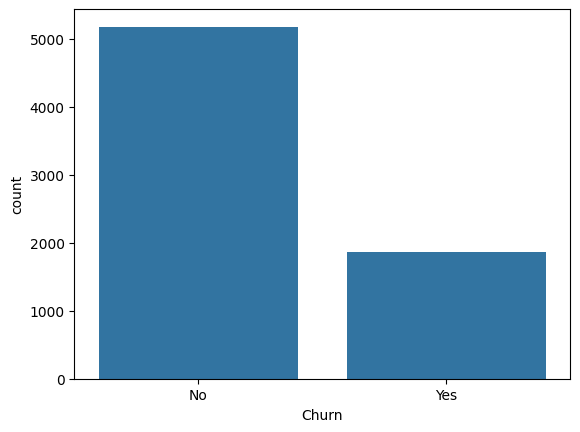

In [10]:
sns.countplot(x = 'Churn', data = df)
plt.show()

In [11]:
# Data Cleaning
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')

In [13]:
df.isnull().sum().sum()

np.int64(11)

In [14]:
df.dropna(inplace = True)

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
df.drop(['customerID'],axis = 1, inplace = True)

In [17]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [18]:
df.shape

(7032, 20)

In [19]:
(df['Churn'].value_counts(normalize = True)*100).round(2)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

In [20]:
# There is 73% customer who didn't churn and churn customer is 26%
# here is class imbalance 73% No and 26% yes

In [21]:
# Exploratory Data Analysis

In [22]:
cat_cols = df.select_dtypes(include = 'object').columns

In [23]:
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

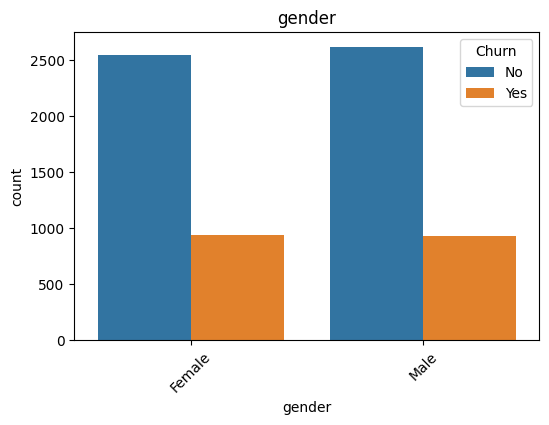

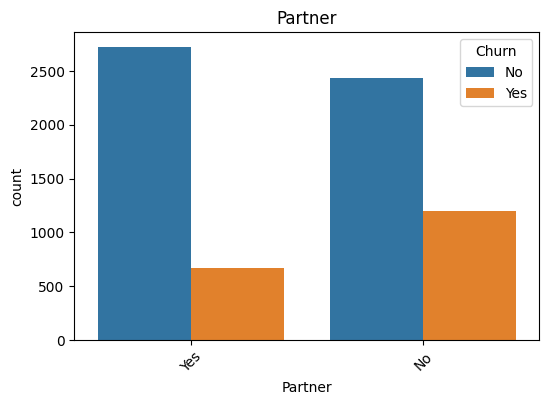

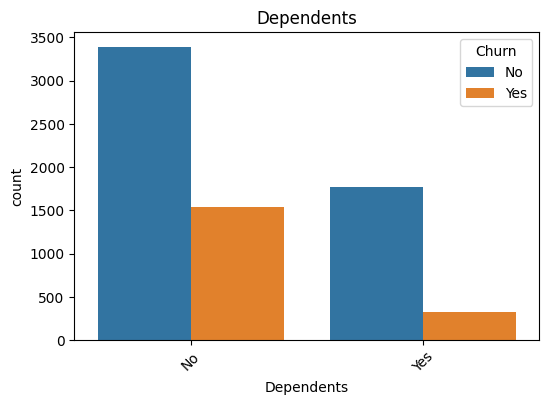

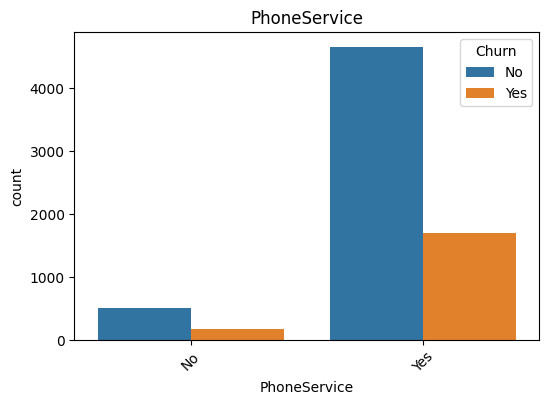

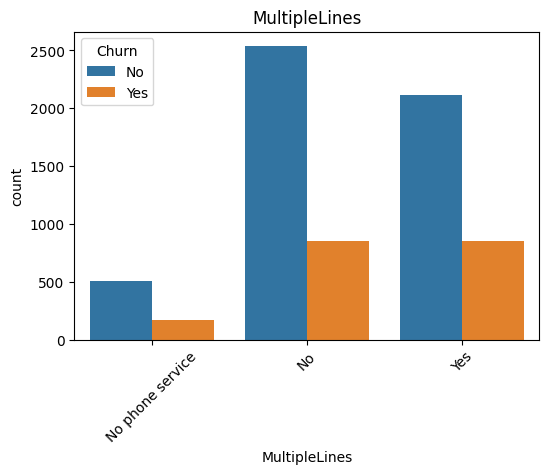

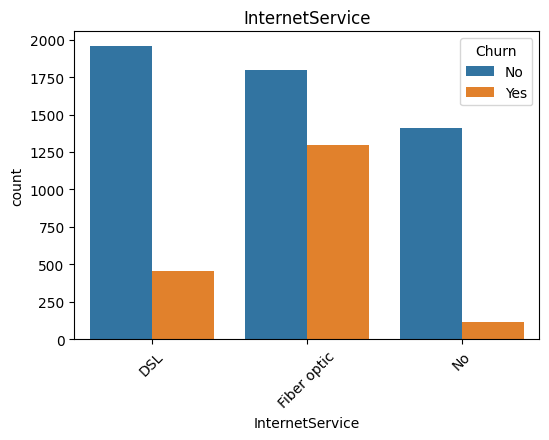

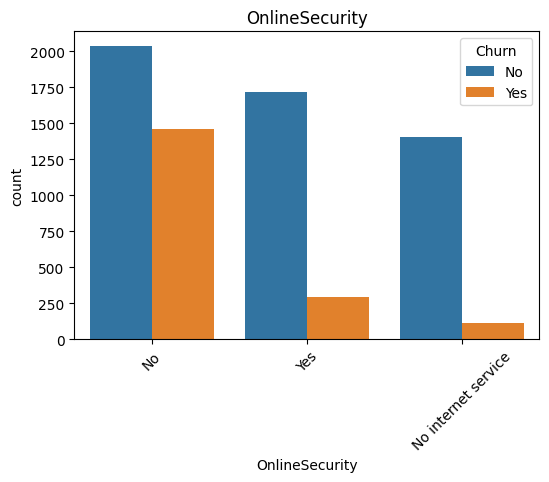

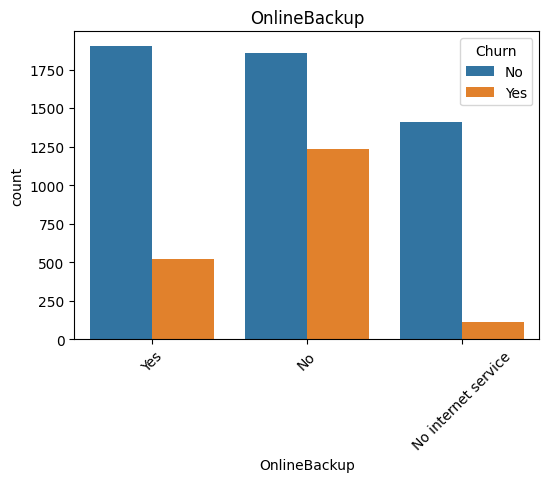

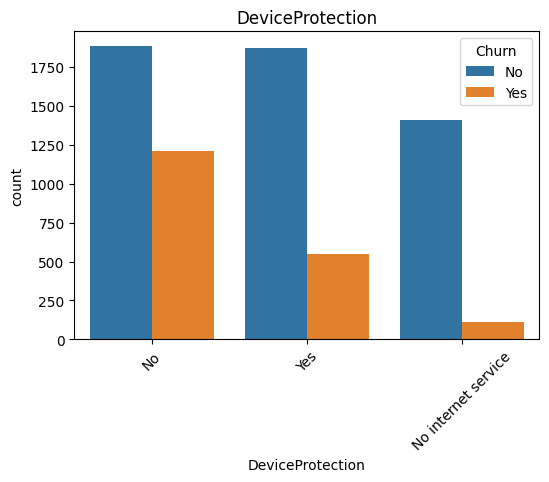

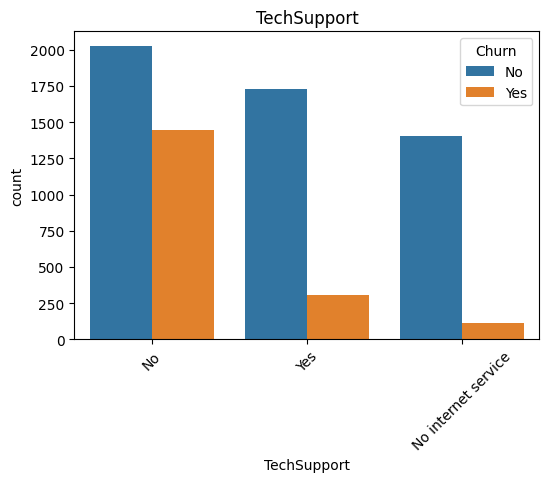

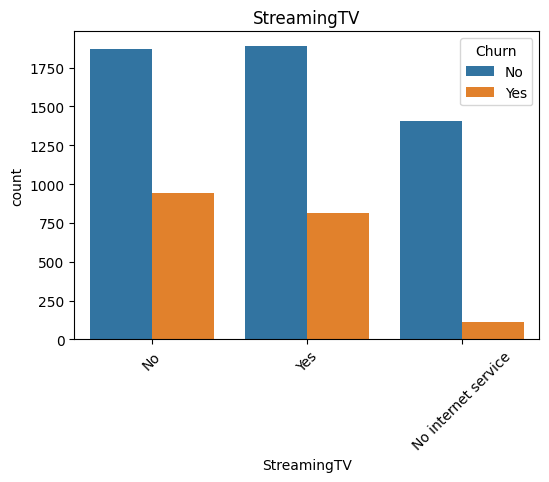

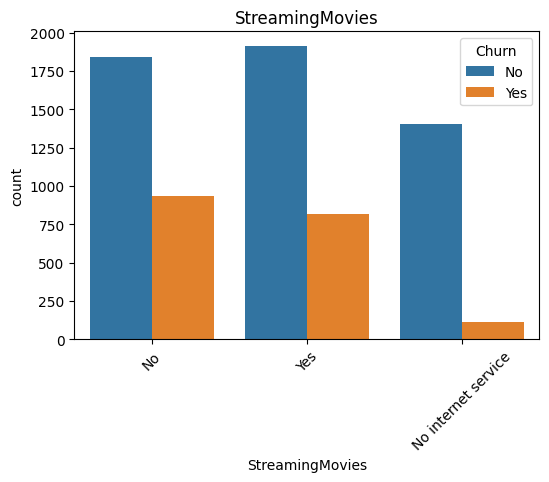

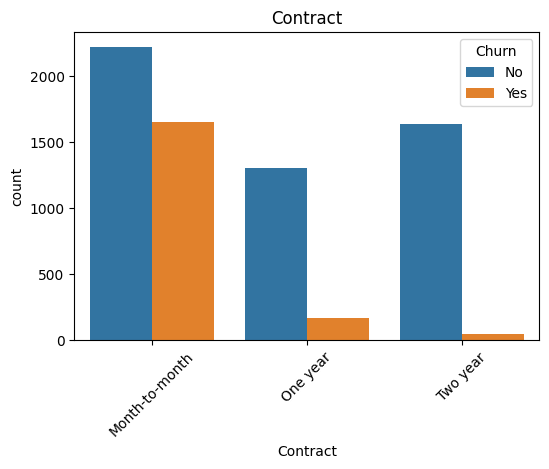

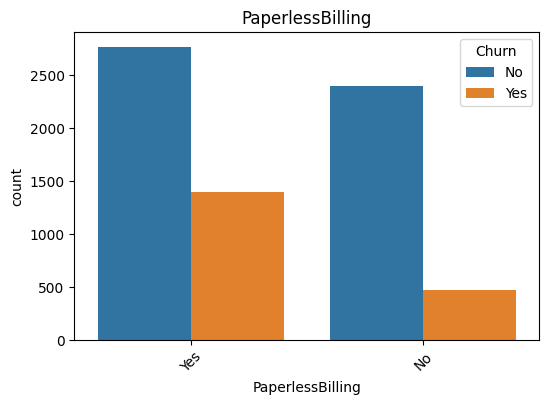

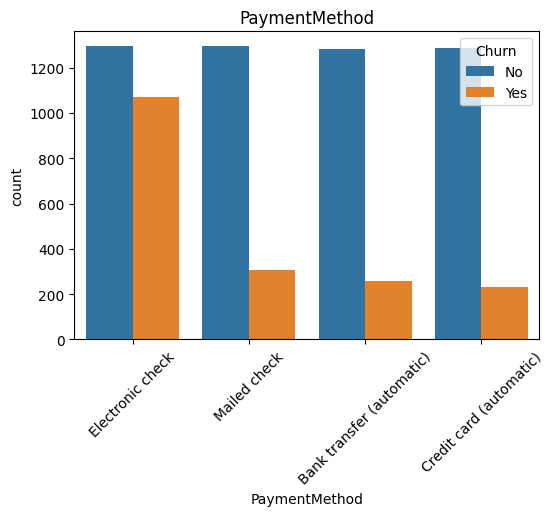

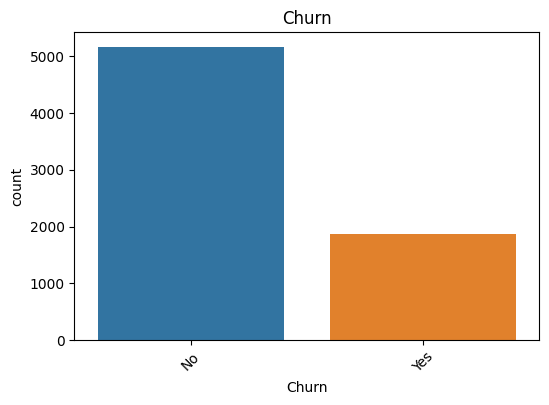

In [24]:
for col in cat_cols:
    plt.figure(figsize = (6,4))
    sns.countplot(x = col,hue = 'Churn',data = df)
    plt.xticks(rotation = 45)
    plt.title(col)
    plt.show()
    

In [25]:
num_cols = df.select_dtypes(include = ['float','int']).columns

In [26]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [27]:
df[num_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SeniorCitizen   7032 non-null   int64  
 1   tenure          7032 non-null   int64  
 2   MonthlyCharges  7032 non-null   float64
 3   TotalCharges    7032 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 274.7 KB


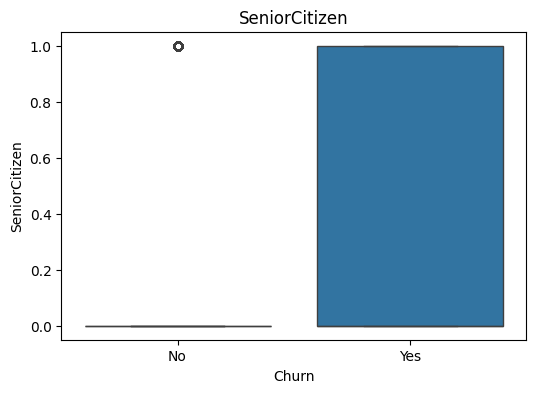

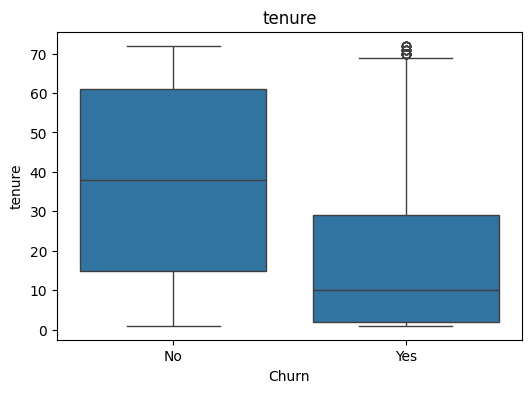

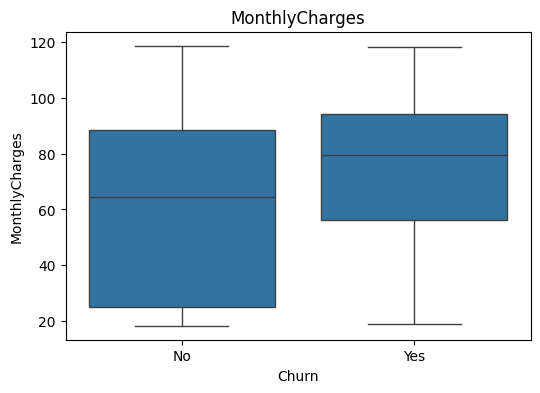

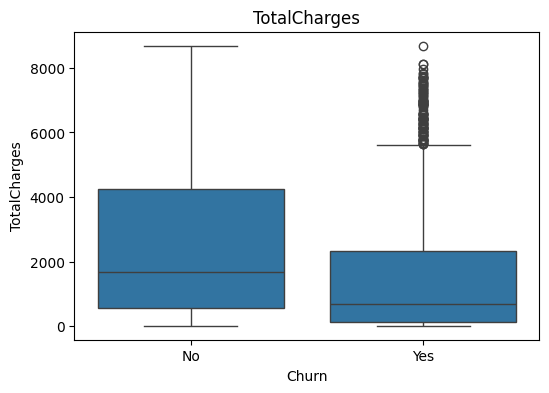

In [28]:
for col in num_cols:
    plt.figure(figsize = (6,4))
    sns.boxplot(x = 'Churn',y = col,data = df)
    plt.title(col)
    plt.show()

In [29]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [30]:
df['Churn'].value_counts(normalize = True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

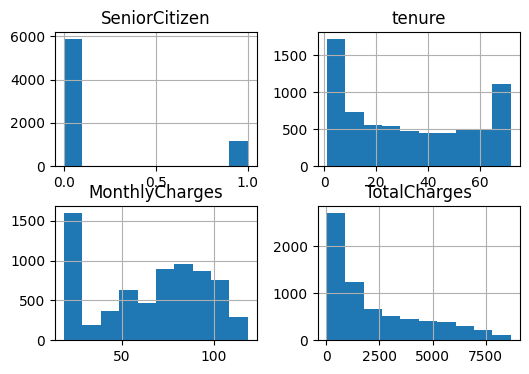

In [31]:
df[num_cols].hist(figsize = (6,4))

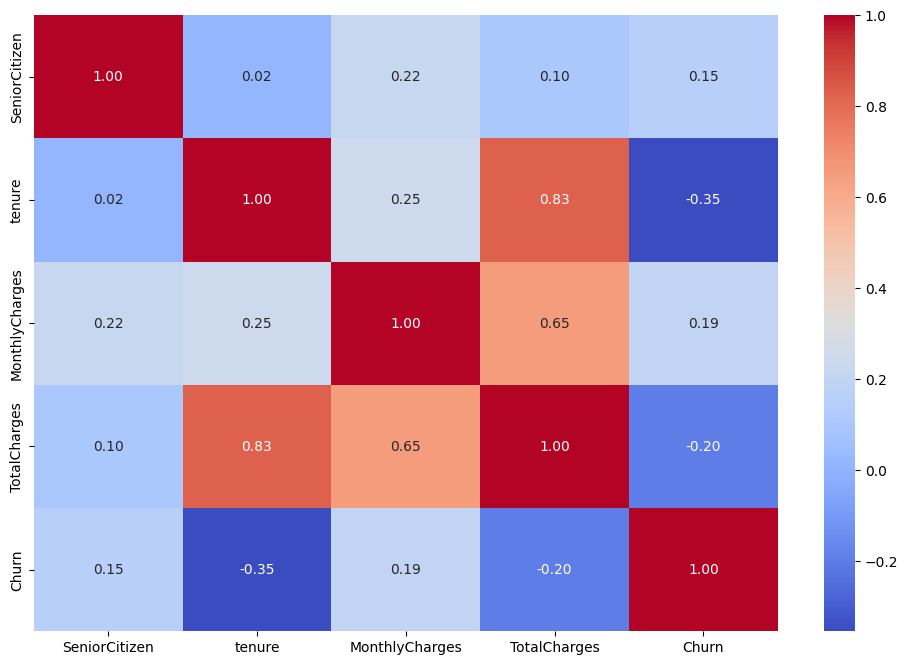

In [32]:
plt.figure(figsize = (12,8))
sns.heatmap(df.corr(numeric_only = True),annot = True,cmap = 'coolwarm',fmt = '.2f')
plt.show()

In [33]:
# from correlation matrix it can be shown that churning customer is negatively affected by
# TotlaCharges and Tenure 
# Customer who do payment through electronic check their churning rate is high as compared 
#to other paymentmethod 
# paper less billing churning is high
# whose contract is month to month their churning rate is high
# Phone service and Dependents is also cause of churning high
# customer who are using fiber optic their churning rate is high
# Techsupport is also the main cause for the customer churning



In [34]:
df.shape

(7032, 20)

In [35]:
df = pd.get_dummies(df,drop_first = True)

In [36]:
df.shape

(7032, 31)

In [37]:
X = df.drop(['Churn'],axis = 1)
y = df['Churn']

In [38]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [39]:
# FEATURE SCALING


In [40]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [41]:
# MODEL 1 (LOGISTIC REGRESSION)

In [42]:
lr = LogisticRegression(max_iter = 1000)


In [43]:
lr.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [44]:
lr_pred = lr.predict(x_test)

In [45]:
lr_accuracy = accuracy_score(y_test,lr_pred)
print(lr_accuracy)

0.7874911158493249


In [46]:
# MODEL 2 (RANDOM FOREST)

In [47]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [48]:
rf_pred = rf.predict(x_test)

In [49]:
rf_accuracy = accuracy_score(y_test,rf_pred)
print(rf_accuracy)

0.7810945273631841


In [50]:
# MODEL 3 (XGBOOST)

In [51]:
from xgboost import XGBClassifier

In [52]:
xgb = XGBClassifier()

In [53]:
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [54]:
xgb_pred = xgb.predict(x_test)

In [55]:
xgb_accuracy = accuracy_score(y_test,xgb_pred)
print(xgb_accuracy)

0.7739872068230277


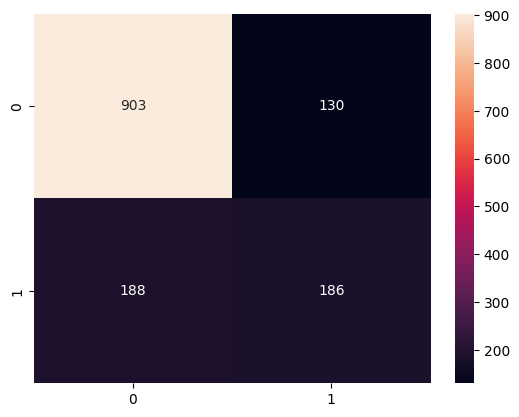

In [56]:
sns.heatmap(confusion_matrix(y_test,xgb_pred),annot = True,fmt = 'd')
plt.show()

In [57]:
roc_auc_score(y_test,xgb_pred)

np.float64(0.6857395778869498)

In [58]:
# FEATURE IMPORTANCE

In [59]:
importance = pd.Series(rf.feature_importances_,index = df.drop(['Churn'],axis = 1).columns)

In [60]:
importance.sort_values(ascending = False).head(15).round(2)

TotalCharges                      0.19
tenure                            0.17
MonthlyCharges                    0.17
InternetService_Fiber optic       0.04
PaymentMethod_Electronic check    0.04
Contract_Two year                 0.03
gender_Male                       0.03
OnlineSecurity_Yes                0.03
Contract_One year                 0.02
PaperlessBilling_Yes              0.02
TechSupport_Yes                   0.02
Partner_Yes                       0.02
OnlineBackup_Yes                  0.02
SeniorCitizen                     0.02
MultipleLines_Yes                 0.02
dtype: float64

<Axes: >

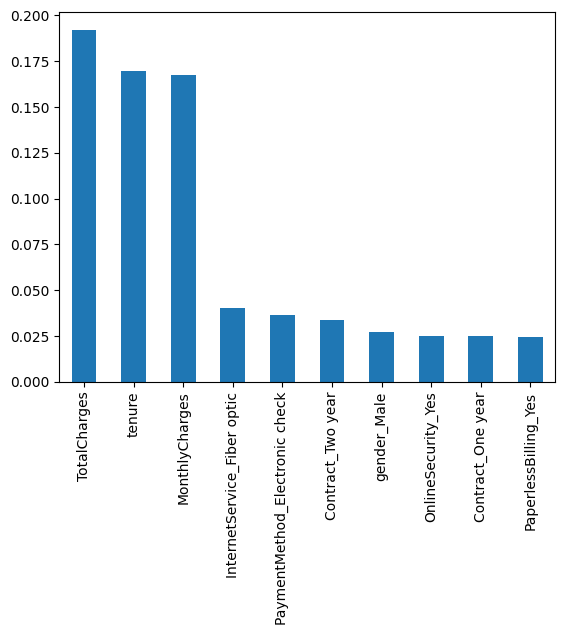

In [61]:
importance.sort_values(ascending = False).head(10).plot.bar()

In [62]:
from imblearn.over_sampling import SMOTE

In [63]:
smote = SMOTE()
x_sm,y_sm = smote.fit_resample(x_train,y_train)

In [64]:
params = {'n_estimators':[100,200],'max_depth':[5,10,20],'min_samples_split':[2,6,8,10],'min_samples_leaf':[1,2]}

In [65]:
from sklearn.model_selection import GridSearchCV

In [66]:
grid = GridSearchCV(rf,params,cv = 5,n_jobs = -1)

In [67]:
grid.fit(x_sm,y_sm)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 6, 8, 10],
                         'n_estimators': [100, 200]})

In [68]:
grid_pred = grid.predict(x_test)

In [69]:
grid_accuracy = accuracy_score(y_test,grid_pred)

In [70]:
print(grid_accuracy)

0.7746979388770433


In [71]:
#SMOTE is applied only on the training data after train-test split to avoid data leakage. 
#The model is then evaluated on the original test dataset to simulate real-world performance

In [72]:
roc_auc_score(y_test,grid_pred)

np.float64(0.7203384566006285)

In [73]:
roc_auc_score(y_test,rf_pred)

np.float64(0.6820511360400889)

After applying SMOTE and hyperparameter tuning, the model's ROC-AUC improved from 0.68 to 0.71, 
indicating better separation between churn and non-churn customers. Although accuracy slightly decreased,
the model improved its ability to detect churn customers,
which is more important for the business.

In [74]:
grid_prob = grid.predict_proba(x_test)[:,1]

In [75]:
print('ROC AUC:',roc_auc_score(y_test,grid_prob))

ROC AUC: 0.8141931242267214


In [76]:
from sklearn.metrics import roc_curve

In [77]:
fpr,Tpr,Threshold = roc_curve(y_test,grid_prob)

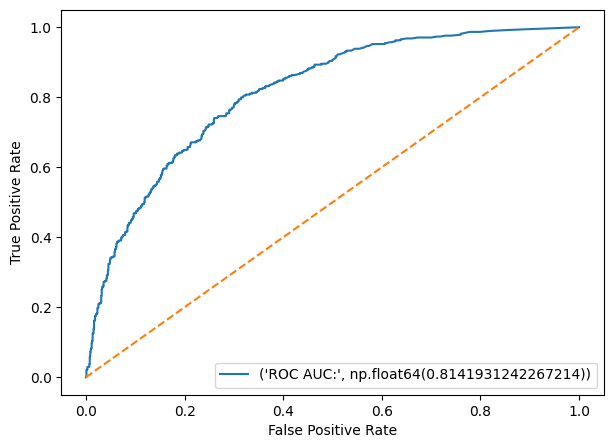

In [78]:
plt.figure(figsize = (7,5))
plt.plot(fpr,Tpr,label = ('ROC AUC:',roc_auc_score(y_test,grid_prob)))
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

What does a good ROC curve look like?

Answer:

A good ROC curve rises quickly toward the top-left corner, indicating high true positive rate and low false positive rate. 
The larger the area under the curve, the better the model’s ability to distinguish between classes.

In [79]:
optimal_idx = np.argmax(Tpr - fpr)

In [80]:
optimal_threshold = Threshold[optimal_idx]

In [81]:
print('optimal_Threshold:',optimal_threshold)

optimal_Threshold: 0.3132767195767196


In [84]:
# Precision-Recall Curve (PR Curve)
#Axis	Meaning
#X-axis	Recall
#Y-axis	Precision

In [85]:
#Precision = TP / (TP + FP)
#Recall = TP / (TP + FN)

In [86]:
from sklearn.metrics import precision_recall_curve

In [90]:
precision,recall,threshold = precision_recall_curve(y_test,grid_prob)

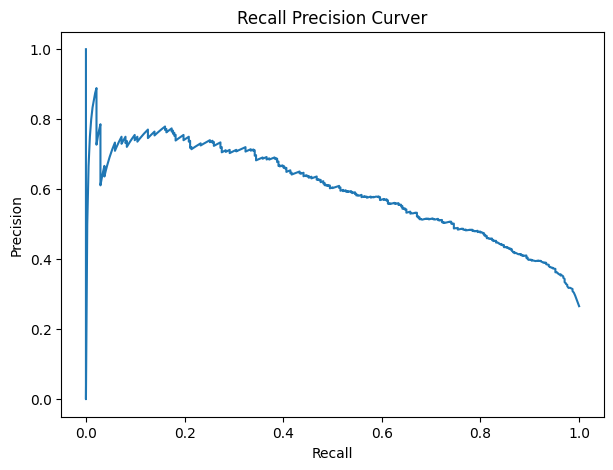

In [91]:
plt.figure(figsize = (7,5))
plt.plot(recall,precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Recall Precision Curver')
plt.show()

In [92]:
# Area under PR curve

In [93]:
from sklearn.metrics import average_precision_score

In [95]:
ap = average_precision_score(y_test,grid_prob)
print('average precision:',ap)

average precision: 0.596945017805949


In [96]:
#Metric	Best use
#ROC Curve	balanced dataset
#PR Curve	imbalanced dataset

The precision–recall curve shows the trade-off between detecting more churn customers and maintaining prediction accuracy.
As recall increases, precision decreases because the model starts flagging more customers as churn. 
The average precision score of about 0.60 indicates the model has moderate
performance in identifying churn customers in an imbalanced dataset.
The model maintains around 70% precision when recall is about 30–40%, which is useful for targeted retention campaigns.

In [97]:
import pickle

pickle.dump(grid,open("churn_model.pkl","wb"))
pickle.dump(scaler,open("scaler.pkl","wb"))
pickle.dump(X.columns,open("columns.pkl","wb"))